# Get data

In [1]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
import re
import xml.etree.ElementTree as ET
from functools import reduce
import openpyxl
from scipy.optimize import minimize_scalar
import numpy as np
import glob

pd.set_option('display.max_columns', None)

In [2]:
BUDGET_BASE_URL = "https://bank.gov.ua/NBUStatService/v1/statdirectory/budget"
INCOME_URL = "https://index.minfin.com.ua/ua/finance/budget/cons/income/2024/"
EXPENSE_URL = "https://index.minfin.com.ua/ua/finance/budget/cons/expense/2024/"

In [3]:
params = {
        "start": "20100101",
        "end": "20231231",
        "period": "m",
        # "id_api": "gf_budgtr_10000000",
        "mcr200p": "CBU",
        # "mcr210ipf": "2",
        "json": ""
    }

response = requests.get(BUDGET_BASE_URL, params=params, timeout=30)
response.raise_for_status()

data = response.json()
df = pd.DataFrame(data)

df.head()

,dt,txt,txten,id_api,leveli,parent,freq,mcr200p,tzep,value
0,20160101,Запозичення,Borrowing,gf_budgtfd_401000,2,budgtfd_400000,M,CBU,F_M_VC,514159.0
1,20160101,Погашення,Repayment,gf_budgtfd_402000,2,budgtfd_400000,M,CBU,F_M_VC,-429899.3
2,20160101,Коригування,Adjustments,gf_budgtfd_403000,2,budgtfd_400000,M,CBU,F_M_VC,30554.5
3,20160101,Фінансування за борговими операціями,Financing under debt transactions,gf_budgtfd_400000,1,budgtfd_Total,M,CBU,F_M_VC,114814.2
4,20160101,Фінансування за рахунок надходжень від привати...,Privatization,gf_budgtfd_500000,1,budgtfd_Total,M,CBU,F_M_VC,151.5


In [4]:
tax_df = df[df["id_api"].isin(['gf_budgtr_10000000', 'gf_budgtr_14060000', 'gf_budgtr_14070000', 'gf_budgtr_14020000', 'gf_budgtr_14030000', 'gf_budgtr_14040000', 'gf_budgtef_Total_1'])].copy()
tax_df["dt"] = pd.to_datetime(tax_df["dt"], format="%Y%m%d", errors="coerce")

tax_df["value"] = pd.to_numeric(tax_df["value"], errors="coerce")
tax_df['value'] = tax_df['value'] * 1e6

keep_cols = [c for c in [
    "dt", "id_api", "txt", "mcr200p", "mcr210ipf", "freq", "value"
] if c in tax_df.columns]

tax_df = (
    tax_df[keep_cols]
    .sort_values("dt")
    .reset_index(drop=True)
)

tax_df["dt"] = tax_df["dt"] - pd.offsets.MonthBegin(1)
tax_df

,dt,id_api,txt,mcr200p,freq,value
0,2011-01-01,gf_budgtr_14040000,Акцизний податок з реалізації суб’єктами госпо...,CBU,M,0.000000e+00
1,2011-01-01,gf_budgtr_14070000,Податок на додану вартість з ввезених на терит...,CBU,M,5.163000e+09
2,2011-01-01,gf_budgtr_10000000,Податкові надходження,CBU,M,1.865610e+10
3,2011-01-01,gf_budgtr_14020000,Акцизний податок з вироблених в Україні підакц...,CBU,M,2.387800e+09
4,2011-01-01,gf_budgtr_14030000,Акцизний податок з ввезених на митну територію...,CBU,M,3.921000e+08
...,...,...,...,...,...,...
1072,2023-11-01,gf_budgtr_14070000,Податок на додану вартість з ввезених на терит...,CBU,M,3.304373e+11
1073,2023-11-01,gf_budgtr_14020000,Акцизний податок з вироблених в Україні підакц...,CBU,M,8.561510e+10
1074,2023-11-01,gf_budgtr_10000000,Податкові надходження,CBU,M,1.486210e+12
1075,2023-11-01,gf_budgtr_14040000,Акцизний податок з реалізації суб’єктами госпо...,CBU,M,1.292930e+10


In [5]:
df_wide = tax_df.pivot(index='dt', columns='id_api', values='value').reset_index()
df_wide = df_wide.rename(columns={
    'gf_budgtr_10000000': 'total_tax_revenue',
    'gf_budgtr_14060000': 'vat_domestic',
    'gf_budgtr_14070000': 'vat_imported',
    'gf_budgtr_14020000': 'excise_on_produced',
    'gf_budgtr_14030000': 'excise_on_imported',
    'gf_budgtr_14040000': 'excise_on_excise',
    'gf_budgtef_Total_1': 'total_budget_payouts',
    'id_api': 'id'
})

df_cols = [col for col in df_wide.columns if col not in ['dt', 'id']]

tax_quarterly_cum = (
    df_wide.set_index("dt")
         .resample("QE")[df_cols]
         .last()
         .reset_index()
)

tax_quarterly_cum["quarter"] = tax_quarterly_cum["dt"].dt.to_period("Q").astype(str)
tax_quarterly_cum.head()

id_api,dt,total_budget_payouts,total_tax_revenue,excise_on_produced,excise_on_imported,excise_on_excise,vat_domestic,vat_imported,quarter
0,2011-03-31,8.450490e+10,7.304560e+10,5.419100e+09,1.479000e+09,0.0,1.069270e+10,1.865320e+10,2011Q1
1,2011-06-30,1.875947e+11,1.537056e+11,1.178450e+10,3.094100e+09,0.0,1.847550e+10,4.104550e+10,2011Q2
2,2011-09-30,2.870438e+11,2.424213e+11,1.951500e+10,5.503100e+09,0.0,2.561380e+10,6.957800e+10,2011Q3
3,2011-12-31,4.168536e+11,3.346919e+11,2.609710e+10,7.822100e+09,0.0,3.406880e+10,9.602500e+10,2011Q4
4,2012-03-31,9.899970e+10,8.356080e+10,5.916000e+09,2.204600e+09,0.0,8.483200e+09,2.308820e+10,2012Q1


## 2023Q3-2024

In [ ]:
import re
import requests
import pandas as pd
from bs4 import BeautifulSoup

INCOME_URL = "https://index.minfin.com.ua/ua/finance/budget/cons/income/2024/"

def parse_ua_number(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    x = x.replace("\xa0", "").replace(" ", "").replace(",", ".")
    x = re.sub(r"[^\d\.-]", "", x)
    return float(x) if x else None


def get_page_text(url):
    headers = {"User-Agent": "Mozilla/5.0"}
    r = requests.get(url, headers=headers, timeout=60)
    r.raise_for_status()
    soup = BeautifulSoup(r.text, "html.parser")
    return soup.get_text("\n", strip=True)


def extract_annual_value(text, label, code=None):
    label_esc = re.escape(label)
    label_esc = label_esc.replace(r"\ ", r"\s+")

    if code is not None:
        pattern = rf"{label_esc}\s+{re.escape(str(code))}\s+([\d\s\xa0]+,\d+)"
    else:
        pattern = rf"{label_esc}\s+([\d\s\xa0]+,\d+)"

    m = re.search(pattern, text, flags=re.IGNORECASE)
    if not m:
        raise ValueError(f"Could not find annual value for {label!r}")

    return parse_ua_number(m.group(1))


def extract_monthly_flows(text, year=2024):
    month_map = {
        "січень": 1,
        "лютий": 2,
        "березень": 3,
        "квітень": 4,
        "травень": 5,
        "червень": 6,
        "липень": 7,
        "серпень": 8,
        "вересень": 9,
        "жовтень": 10,
        "листопад": 11,
        "грудень": 12,
    }

    matches = re.findall(
        r"за\s+(січень|лютий|березень|квітень|травень|червень|липень|серпень|вересень|жовтень|листопад|грудень)\s+([\d\s\xa0]+,\d+)",
        text,
        flags=re.IGNORECASE
    )

    if not matches:
        raise ValueError("No monthly values found")

    monthly_df = pd.DataFrame(
        [{"month_num": month_map[m.lower()], "monthly_value": parse_ua_number(v)}
         for m, v in matches]
    ).drop_duplicates(subset=["month_num"]).sort_values("month_num")

    monthly_df["month"] = pd.to_datetime(
        f"{year}-" + monthly_df["month_num"].astype(str).str.zfill(2) + "-01"
    )

    return monthly_df.reset_index(drop=True)


def add_missing_december_from_annual_total(monthly_df, annual_total_for_weights, year=2024):
    monthly_df = monthly_df.copy()
    present_months = set(monthly_df["month_num"])

    if present_months == set(range(1, 12)):
        dec_value = annual_total_for_weights - monthly_df["monthly_value"].sum()
        dec_row = pd.DataFrame({
            "month_num": [12],
            "monthly_value": [dec_value],
            "month": [pd.Timestamp(f"{year}-12-01")]
        })
        monthly_df = pd.concat([monthly_df, dec_row], ignore_index=True)
    elif present_months != set(range(1, 13)):
        raise ValueError(f"Unexpected months found: {sorted(present_months)}")

    return monthly_df.sort_values("month_num").reset_index(drop=True)


def get_quarter_weights(monthly_df):
    q = (
        monthly_df.assign(quarter=monthly_df["month"].dt.to_period("Q"))
        .groupby("quarter", as_index=False)["monthly_value"]
        .sum()
        .rename(columns={"monthly_value": "quarter_sum"})
    )
    q["share"] = q["quarter_sum"] / q["quarter_sum"].sum()
    return q


def allocate_annual_to_quarters(annual_value, q_weights, series_name):
    out = q_weights.copy()
    out["dt"] = out["quarter"].dt.end_time.dt.normalize()
    out["series"] = series_name
    out["value"] = annual_value * out["share"] * 1e6   # mln UAH -> UAH
    return out[["dt", "quarter", "series", "value"]]


def scrape_income_2024_selected(url=INCOME_URL):
    text = get_page_text(url)

    annual_total_for_weights = extract_annual_value(
        text,
        "Усього (без урахування міжбюджетних трансфертів)"
    )

    monthly_df = extract_monthly_flows(text, year=2024)
    monthly_df = add_missing_december_from_annual_total(
        monthly_df,
        annual_total_for_weights=annual_total_for_weights,
        year=2024
    )
    q_weights = get_quarter_weights(monthly_df)

    annual_tax_revenue = extract_annual_value(
        text,
        "Податкові надходження",
        code="10000000"
    )

    annual_internal_taxes_goods_services = extract_annual_value(
        text,
        "Внутрішні податки на товари та послуги",
        code="14000000"
    )

    result = pd.concat([
        allocate_annual_to_quarters(
            annual_tax_revenue,
            q_weights,
            "Податкові надходження"
        ),
        allocate_annual_to_quarters(
            annual_internal_taxes_goods_services,
            q_weights,
            "Внутрішні податки на товари та послуги"
        )
    ], ignore_index=True)

    return result

In [7]:
income_2024 = scrape_income_2024_selected()
income_2024

,dt,quarter,series,value
0,2024-03-31,2024Q1,Податкові надходження,4.348813e+11
1,2024-06-30,2024Q2,Податкові надходження,4.562410e+11
2,2024-09-30,2024Q3,Податкові надходження,5.659132e+11
3,2024-12-31,2024Q4,Податкові надходження,6.312483e+11
4,2024-03-31,2024Q1,Внутрішні податки на товари та послуги,2.025630e+11
5,2024-06-30,2024Q2,Внутрішні податки на товари та послуги,2.125121e+11
6,2024-09-30,2024Q3,Внутрішні податки на товари та послуги,2.635962e+11
7,2024-12-31,2024Q4,Внутрішні податки на товари та послуги,2.940286e+11


In [8]:
import re
import requests
import pandas as pd
from bs4 import BeautifulSoup

EXPENSE_URL = "https://index.minfin.com.ua/ua/finance/budget/cons/expense/2024/"

def parse_ua_number(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    x = x.replace("\xa0", "").replace(" ", "").replace(",", ".")
    x = re.sub(r"[^\d\.-]", "", x)
    return float(x) if x else None


def get_page_text(url):
    headers = {"User-Agent": "Mozilla/5.0"}
    r = requests.get(url, headers=headers, timeout=60)
    r.raise_for_status()
    soup = BeautifulSoup(r.text, "html.parser")
    text = soup.get_text("\n", strip=True)
    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def extract_monthly_flows(text, year):
    month_map = {
        "січень": 1,
        "лютий": 2,
        "березень": 3,
        "квітень": 4,
        "травень": 5,
        "червень": 6,
        "липень": 7,
        "серпень": 8,
        "вересень": 9,
        "жовтень": 10,
        "листопад": 11,
        "грудень": 12,
    }

    matches = re.findall(
        r"за\s+(січень|лютий|березень|квітень|травень|червень|липень|серпень|вересень|жовтень|листопад|грудень)\s+([\d\s]+,\d+)",
        text,
        flags=re.IGNORECASE
    )

    if not matches:
        raise ValueError("No monthly values found")

    monthly_df = pd.DataFrame(
        [{"month_num": month_map[m.lower()], "monthly_value": parse_ua_number(v)}
         for m, v in matches]
    ).drop_duplicates(subset=["month_num"]).sort_values("month_num")

    monthly_df["month"] = pd.to_datetime(
        f"{year}-" + monthly_df["month_num"].astype(str).str.zfill(2) + "-01"
    )

    return monthly_df.reset_index(drop=True)


def extract_expense_total(text, year):
    pattern = rf"Видатки зведеного бюджету України \(функціональна класифікація\) у\s*{year}\s*р\..*?Усього\s+([\d\s]+,\d+)\s+\d+\.\d+%"
    m = re.search(pattern, text, flags=re.IGNORECASE)
    if not m:
        raise ValueError(f"Could not find annual functional-classification total 'Усього' for {year}")
    return parse_ua_number(m.group(1))


def get_quarter_weights(monthly_df):
    q = (
        monthly_df.assign(quarter=monthly_df["month"].dt.to_period("Q"))
        .groupby("quarter", as_index=False)["monthly_value"]
        .sum()
        .rename(columns={"monthly_value": "quarter_sum"})
    )
    q["share"] = q["quarter_sum"] / q["quarter_sum"].sum()
    return q


def scrape_expense_total(url, year):
    text = get_page_text(url)

    annual_total = extract_expense_total(text, year=year)
    monthly_df = extract_monthly_flows(text, year=year)
    q_weights = get_quarter_weights(monthly_df)

    result = q_weights.copy()
    result["dt"] = result["quarter"].dt.end_time.dt.normalize()
    result["series"] = "Усього"
    result["value"] = annual_total * result["share"] * 1e6

    return result[["dt", "quarter", "series", "value"]]

In [9]:
expense_2024 = scrape_expense_total(url="https://index.minfin.com.ua/ua/finance/budget/cons/expense/2024/", year=2024)

expense_2024_wide = (
    expense_2024
    .pivot(index="dt", columns="series", values="value")
    .reset_index()
)
expense_2024_wide.columns.name = None
expense_2024

,dt,quarter,series,value
0,2024-03-31,2024Q1,Усього,9.163898e+11
1,2024-06-30,2024Q2,Усього,1.179678e+12
2,2024-09-30,2024Q3,Усього,1.140286e+12
3,2024-12-31,2024Q4,Усього,1.707672e+12


In [ ]:
expense_2023 = scrape_expense_total(
    url="https://index.minfin.com.ua/ua/finance/budget/cons/expense/2023/",
    year=2023
)

expense_2023_wide = (
    expense_2023
    .pivot(index="dt", columns="series", values="value")
    .reset_index()
)
expense_2023_wide.columns.name = None

expense_2023_wide = expense_2023_wide[expense_2023_wide['dt'] >= pd.Timestamp("2023-09-30")]
expense_2024_wide = expense_2024_wide.rename(columns={"value": "Усього"})

In [11]:
income_2024_wide = (
    scrape_income_2024_selected()
    .pivot(index="dt", columns="series", values="value")
    .reset_index()
)
income_2024_wide.columns.name = None

final_2024 = income_2024_wide.merge(expense_2024_wide, on="dt", how="outer").sort_values("dt")
final_2024["year-quarter"] = final_2024["dt"].dt.to_period("Q").astype(str)
final_2024 = final_2024.rename(columns={
    "Податкові надходження": "tax_revenue",
    "Усього": "total_expense",
    'Внутрішні податки на товари та послуги': 'internal_taxes_goods_services'
})
final_2024

,dt,internal_taxes_goods_services,tax_revenue,total_expense,year-quarter
0,2024-03-31,2.025630e+11,4.348813e+11,9.163898e+11,2024Q1
1,2024-06-30,2.125121e+11,4.562410e+11,1.179678e+12,2024Q2
2,2024-09-30,2.635962e+11,5.659132e+11,1.140286e+12,2024Q3
3,2024-12-31,2.940286e+11,6.312483e+11,1.707672e+12,2024Q4


In [12]:
tax_quarterly_cum['internal_taxes_goods_services'] = tax_quarterly_cum['excise_on_produced'] + tax_quarterly_cum['excise_on_imported'] + tax_quarterly_cum['excise_on_excise'] + tax_quarterly_cum['vat_domestic'] + tax_quarterly_cum['vat_imported']
tax_quarterly_cum = tax_quarterly_cum.rename(columns={
    'total_tax_revenue': 'tax_revenue',
    'total_budget_payouts': 'total_expense',
    'quarter': 'year-quarter'
})

tax_quarterly_cum = tax_quarterly_cum[['year-quarter', 'tax_revenue', 'total_expense', 'internal_taxes_goods_services']]

expense_2023_wide["year-quarter"] = pd.to_datetime(expense_2023_wide["dt"]).dt.to_period("Q").astype(str)

mapping = expense_2023_wide.set_index("year-quarter")["Усього"]

tax_quarterly_cum["total_expense"] = tax_quarterly_cum["total_expense"].fillna(tax_quarterly_cum["year-quarter"].map(mapping))
tax_quarterly_cum.tail()

id_api,year-quarter,tax_revenue,total_expense,internal_taxes_goods_services
47,2022Q4,1.343225e+12,3.043871e+12,5.824354e+11
48,2023Q1,3.533485e+11,8.095034e+11,1.569495e+11
49,2023Q2,7.423443e+11,1.524719e+12,3.372417e+11
50,2023Q3,1.178698e+12,1.125611e+12,5.486023e+11
51,2023Q4,1.486210e+12,1.377757e+12,6.965592e+11


In [13]:
final_2024 = final_2024[['year-quarter', 'tax_revenue', 'total_expense', 'internal_taxes_goods_services']]

taxes = pd.concat([final_2024, tax_quarterly_cum], ignore_index=True).sort_values("year-quarter").reset_index(drop=True)
taxes

,year-quarter,tax_revenue,total_expense,internal_taxes_goods_services
0,2011Q1,7.304560e+10,8.450490e+10,3.624400e+10
1,2011Q2,1.537056e+11,1.875947e+11,7.439960e+10
2,2011Q3,2.424213e+11,2.870438e+11,1.202099e+11
3,2011Q4,3.346919e+11,4.168536e+11,1.640130e+11
4,2012Q1,8.356080e+10,9.899970e+10,3.969200e+10
5,2012Q2,1.762035e+11,2.169237e+11,8.591400e+10
6,2012Q3,2.636255e+11,3.357593e+11,1.301962e+11
7,2012Q4,3.605672e+11,4.924547e+11,1.772556e+11
8,2013Q1,8.764330e+10,1.121028e+11,3.862470e+10
9,2013Q2,1.741987e+11,2.391358e+11,7.985300e+10


## 2010

In [14]:
# taken from https://cost.ua/byudzhet-ukrayiny/revenue/main/
tax_revenue_2010 = 278 * 1e9
internal_taxes_goods_services_2010 = (28+53.6) * 1e9
# https://ips.ligazakon.net/document/jf4zc00a
total_expense_2010 = 324.37 * 1e9

In [ ]:
df = tax_quarterly_cum.copy()

df["year"] = df["year-quarter"].str[:4].astype(int)
df["q"] = df["year-quarter"].str[-2:]

cols = ["tax_revenue", "total_expense", "internal_taxes_goods_services"]

df = df.sort_values(["year", "q"])

for col in cols:
    df[f"{col}_flow"] = df.groupby("year")[col].diff()
    first_q_mask = df["q"] == "Q1"
    df.loc[first_q_mask, f"{col}_flow"] = df.loc[first_q_mask, col]

annual_totals = (
    df.groupby("year")[[f"{c}_flow" for c in cols]]
    .sum()
    .rename(columns=lambda x: x.replace("_flow", "_annual"))
    .reset_index()
)

df = df.merge(annual_totals, on="year", how="left")

for col in cols:
    df[f"{col}_pct"] = df[f"{col}_flow"] / df[f"{col}_annual"] * 100

avg_pct_by_quarter = (
    df.groupby("q")[[f"{c}_pct" for c in cols]]
    .mean()
    .reset_index()
    .sort_values("q")
)

avg_pct_by_quarter

id_api,q,tax_revenue_pct,total_expense_pct,internal_taxes_goods_services_pct
0,Q1,22.938071,22.563075,22.253427
1,Q2,23.574681,25.923966,23.528759
2,Q3,25.626474,19.500427,26.428759
3,Q4,27.860775,32.012532,27.789055


In [ ]:
avg_pct_by_quarter["tax_revenue_flow"] = tax_revenue_2010 * avg_pct_by_quarter["tax_revenue_pct"] / 100
avg_pct_by_quarter["total_expense_flow"] = total_expense_2010 * avg_pct_by_quarter["total_expense_pct"] / 100
avg_pct_by_quarter["internal_taxes_goods_services_flow"] = (
    internal_taxes_goods_services_2010
    * avg_pct_by_quarter["internal_taxes_goods_services_pct"] / 100
)

avg_pct_by_quarter["tax_revenue"] = avg_pct_by_quarter["tax_revenue_flow"].cumsum()
avg_pct_by_quarter["total_expense"] = avg_pct_by_quarter["total_expense_flow"].cumsum()
avg_pct_by_quarter["internal_taxes_goods_services"] = (
    avg_pct_by_quarter["internal_taxes_goods_services_flow"].cumsum()
)

avg_pct_by_quarter["year-quarter"] = "2010" + avg_pct_by_quarter["q"]

df_2010_final = avg_pct_by_quarter[
    ["year-quarter", "tax_revenue", "total_expense", "internal_taxes_goods_services"]
]

df_2010_final

id_api,year-quarter,tax_revenue,total_expense,internal_taxes_goods_services
0,2010Q1,6.376784e+10,7.318785e+10,1.815880e+10
1,2010Q2,1.293054e+11,1.572774e+11,3.735826e+10
2,2010Q3,2.005470e+11,2.205310e+11,5.892413e+10
3,2010Q4,2.780000e+11,3.243700e+11,8.160000e+10


In [17]:
taxes = pd.concat([df_2010_final, taxes], ignore_index=True).sort_values("year-quarter").reset_index(drop=True)

taxes.head()

,year-quarter,tax_revenue,total_expense,internal_taxes_goods_services
0,2010Q1,6.376784e+10,7.318785e+10,1.815880e+10
1,2010Q2,1.293054e+11,1.572774e+11,3.735826e+10
2,2010Q3,2.005470e+11,2.205310e+11,5.892413e+10
3,2010Q4,2.780000e+11,3.243700e+11,8.160000e+10
4,2011Q1,7.304560e+10,8.450490e+10,3.624400e+10


In [ ]:
taxes["year"] = taxes["year-quarter"].astype(str).str[:4]
taxes["quarter"] = taxes["year-quarter"].astype(str).str[-1].astype(int)

taxes["tax_revenue_flow"] = np.nan

for year in taxes["year"].unique():
    mask = taxes["year"] == year
    sub = taxes.loc[mask].copy().sort_values("quarter")

    for i, (idx, row) in enumerate(sub.iterrows()):
        if row["quarter"] == 1:
            # Q1 is already a flow
            taxes.loc[idx, "tax_revenue_flow"] = row["tax_revenue"]
        else:
            prev_idx = sub.index[i - 1]
            taxes.loc[idx, "tax_revenue_flow"] = (
                row["tax_revenue"] - taxes.loc[prev_idx, "tax_revenue"]
            )

In [ ]:
taxes["total_expense_flow"] = np.nan

for year in taxes["year"].unique():
    mask = taxes["year"] == year
    sub = taxes.loc[mask].copy().sort_values("quarter")

    for i, (idx, row) in enumerate(sub.iterrows()):
        if row["quarter"] == 1:
            taxes.loc[idx, "total_expense_flow"] = row["total_expense"]
        else:
            prev_idx = sub.index[i - 1]
            taxes.loc[idx, "total_expense_flow"] = (
                row["total_expense"] - taxes.loc[prev_idx, "total_expense"]
            )

In [ ]:
taxes["internal_taxes_goods_services_flow"] = np.nan

for year in taxes["year"].unique():
    mask = taxes["year"] == year
    sub = taxes.loc[mask].copy().sort_values("quarter")

    for i, (idx, row) in enumerate(sub.iterrows()):
        if row["quarter"] == 1:
            taxes.loc[idx, "internal_taxes_goods_services_flow"] = row["internal_taxes_goods_services"]
        else:
            prev_idx = sub.index[i - 1]
            taxes.loc[idx, "internal_taxes_goods_services_flow"] = (
                row["internal_taxes_goods_services"] - taxes.loc[prev_idx, "internal_taxes_goods_services"]
            )

In [21]:
taxes.head()

,year-quarter,tax_revenue,total_expense,internal_taxes_goods_services,year,quarter,tax_revenue_flow,total_expense_flow,internal_taxes_goods_services_flow
0,2010Q1,6.376784e+10,7.318785e+10,1.815880e+10,2010,1,6.376784e+10,7.318785e+10,1.815880e+10
1,2010Q2,1.293054e+11,1.572774e+11,3.735826e+10,2010,2,6.553761e+10,8.408957e+10,1.919947e+10
2,2010Q3,2.005470e+11,2.205310e+11,5.892413e+10,2010,3,7.124160e+10,6.325354e+10,2.156587e+10
3,2010Q4,2.780000e+11,3.243700e+11,8.160000e+10,2010,4,7.745295e+10,1.038390e+11,2.267587e+10
4,2011Q1,7.304560e+10,8.450490e+10,3.624400e+10,2011,1,7.304560e+10,8.450490e+10,3.624400e+10


In [22]:
taxes.drop(columns=["year", "quarter", 'tax_revenue', 'total_expense', 'internal_taxes_goods_services'], inplace=True)

taxes = taxes.rename(columns={
    "tax_revenue_flow": "tax_revenue",
    "total_expense_flow": "total_expense",
    "internal_taxes_goods_services_flow": "internal_taxes_goods_services"
})

In [24]:
taxes.to_csv("data/taxes_2010_2024.csv", index=False)

<Axes: xlabel='year-quarter'>

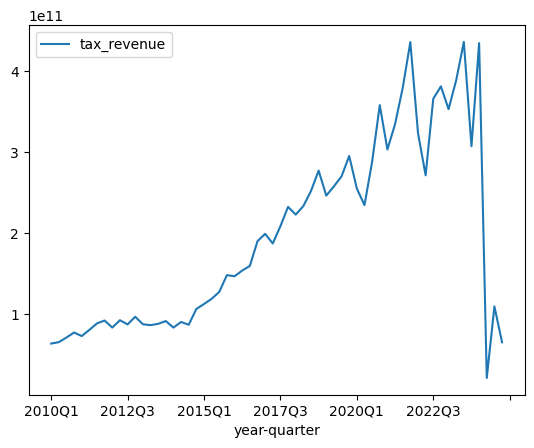

In [25]:
taxes.plot(x="year-quarter", y=["tax_revenue"], kind="line")

In [26]:
taxes

,year-quarter,tax_revenue,total_expense,internal_taxes_goods_services
0,2010Q1,6.376784e+10,7.318785e+10,1.815880e+10
1,2010Q2,6.553761e+10,8.408957e+10,1.919947e+10
2,2010Q3,7.124160e+10,6.325354e+10,2.156587e+10
3,2010Q4,7.745295e+10,1.038390e+11,2.267587e+10
4,2011Q1,7.304560e+10,8.450490e+10,3.624400e+10
5,2011Q2,8.066000e+10,1.030898e+11,3.815560e+10
6,2011Q3,8.871570e+10,9.944910e+10,4.581030e+10
7,2011Q4,9.227060e+10,1.298098e+11,4.380310e+10
8,2012Q1,8.356080e+10,9.899970e+10,3.969200e+10
9,2012Q2,9.264270e+10,1.179240e+11,4.622200e+10
